# Exploratory Data Analysis (EDA)
This notebook performs EDA on the Heart Disease (UCI) dataset: histograms, correlation heatmap, class distribution, missing values analysis, and feature relationships. It also runs preprocessing (missing handling, encoding, scaling) and saves processed train/test CSVs to `data/processed/`.

In [3]:
import os
import glob
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

DATA_PATH = 'data/raw/heart.csv'
if not os.path.exists(DATA_PATH):
	notebook_dir = Path.cwd()
	candidates = []
	for base in [notebook_dir] + list(notebook_dir.parents):
		candidates = list(base.glob('**/heart.csv'))
		if candidates:
			DATA_PATH = str(candidates[0])
			break
	if len(candidates) == 0:
		raise FileNotFoundError(f"Could not find 'heart.csv' under the notebook working directory: {os.getcwd()}")

df = pd.read_csv(DATA_PATH)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
# Basic info and missing values
df.info()
print('\nMissing values per column:')
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target   

In [5]:
# Replace target to binary: 0 -> no disease, 1 -> disease (target>0)
df['target'] = pd.to_numeric(df['target'], errors='coerce')
df['target'] = (df['target'] > 0).astype(int)
df['target'].value_counts()

target
0    164
1    139
Name: count, dtype: int64

## Missing Value Analysis

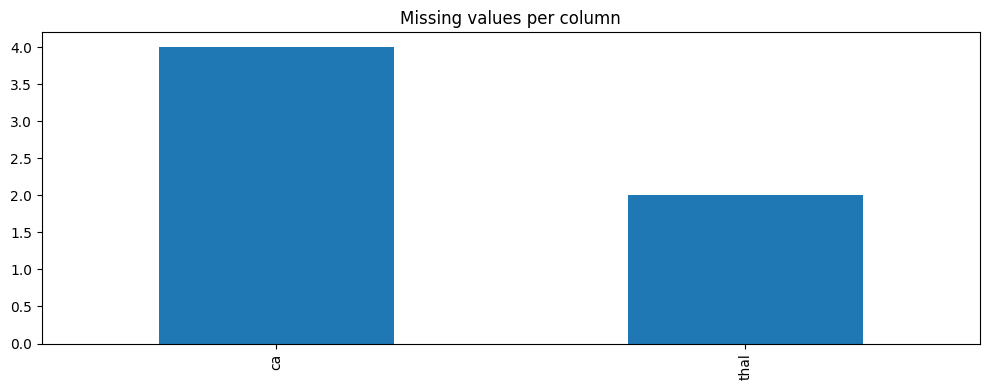

In [6]:
# Visualize missing values (bar plot)
missing = df.isna().sum()
plt.figure(figsize=(10,4))
missing[missing>0].sort_values(ascending=False).plot(kind='bar')
plt.title('Missing values per column')
plt.tight_layout()
os.makedirs('screenshots', exist_ok=True)
plt.savefig('screenshots/missing_values.png')
plt.show()

## Histograms for numerical features

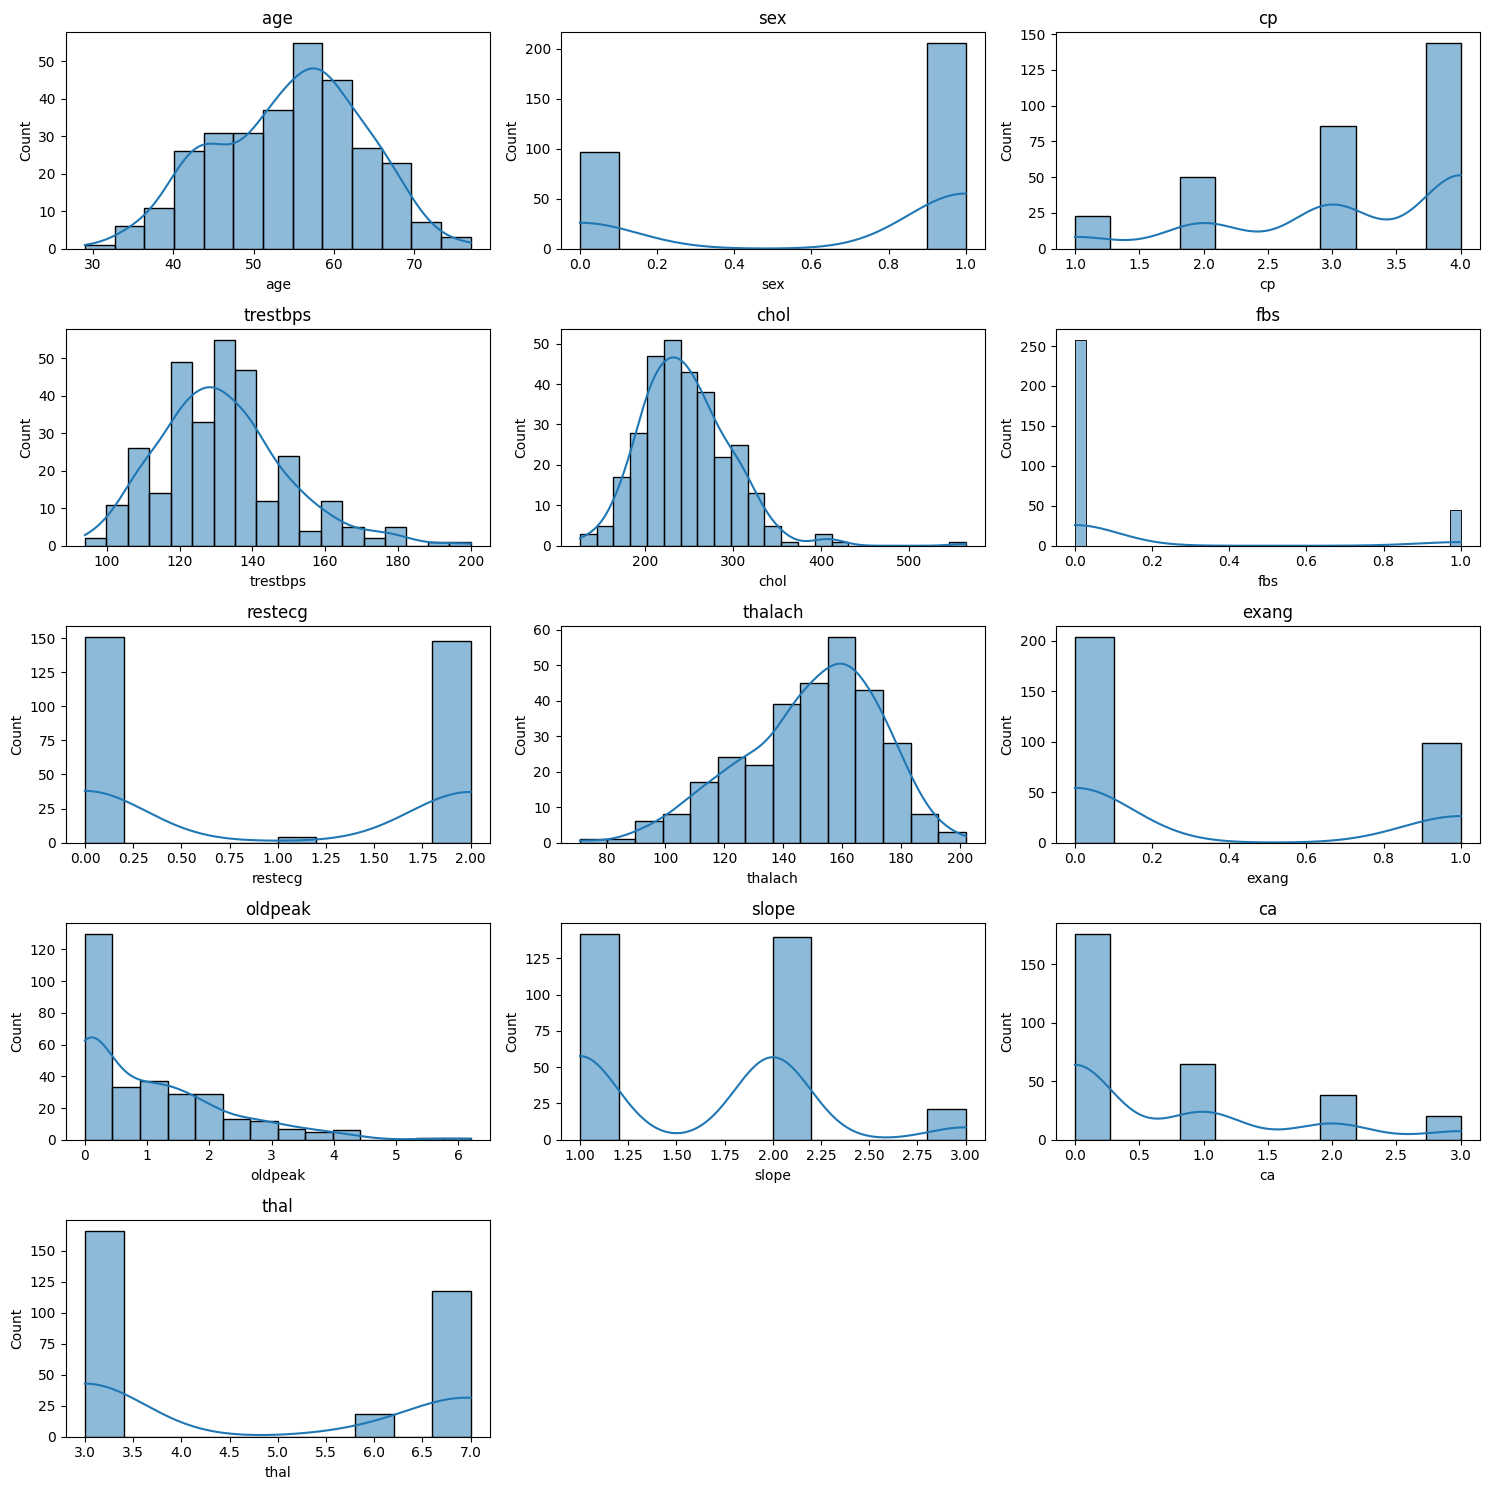

In [7]:
num_cols = df.select_dtypes(include=['number']).columns.drop('target', errors='ignore')
n = len(num_cols)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row
plt.figure(figsize=(cols_per_row*5, rows*3))
for i, c in enumerate(num_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.histplot(df[c].dropna(), kde=True)
    plt.title(c)
plt.tight_layout()
plt.savefig('screenshots/histograms.png')
plt.show()

## Class distribution

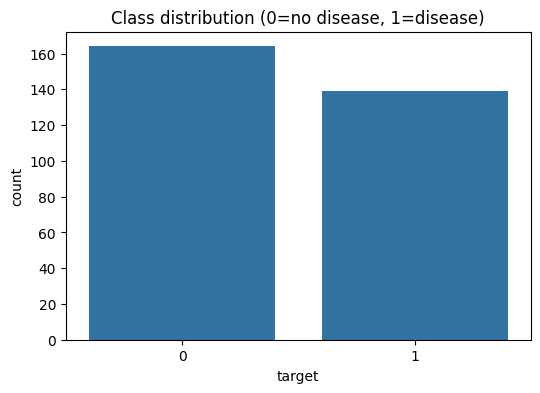

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title('Class distribution (0=no disease, 1=disease)')
plt.savefig('screenshots/class_distribution.png')
plt.show()

## Correlation heatmap (numeric features)

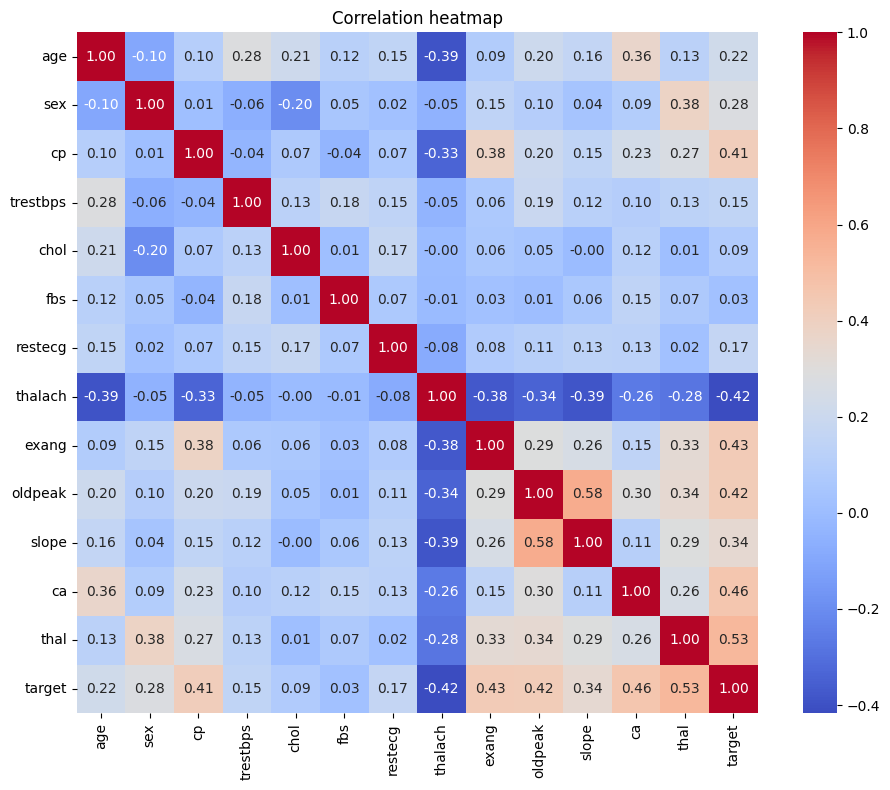

In [9]:
corr = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation heatmap')
plt.tight_layout()
plt.savefig('screenshots/correlation_heatmap.png')
plt.show()

## Feature relationship analysis (pairplots of selected features)

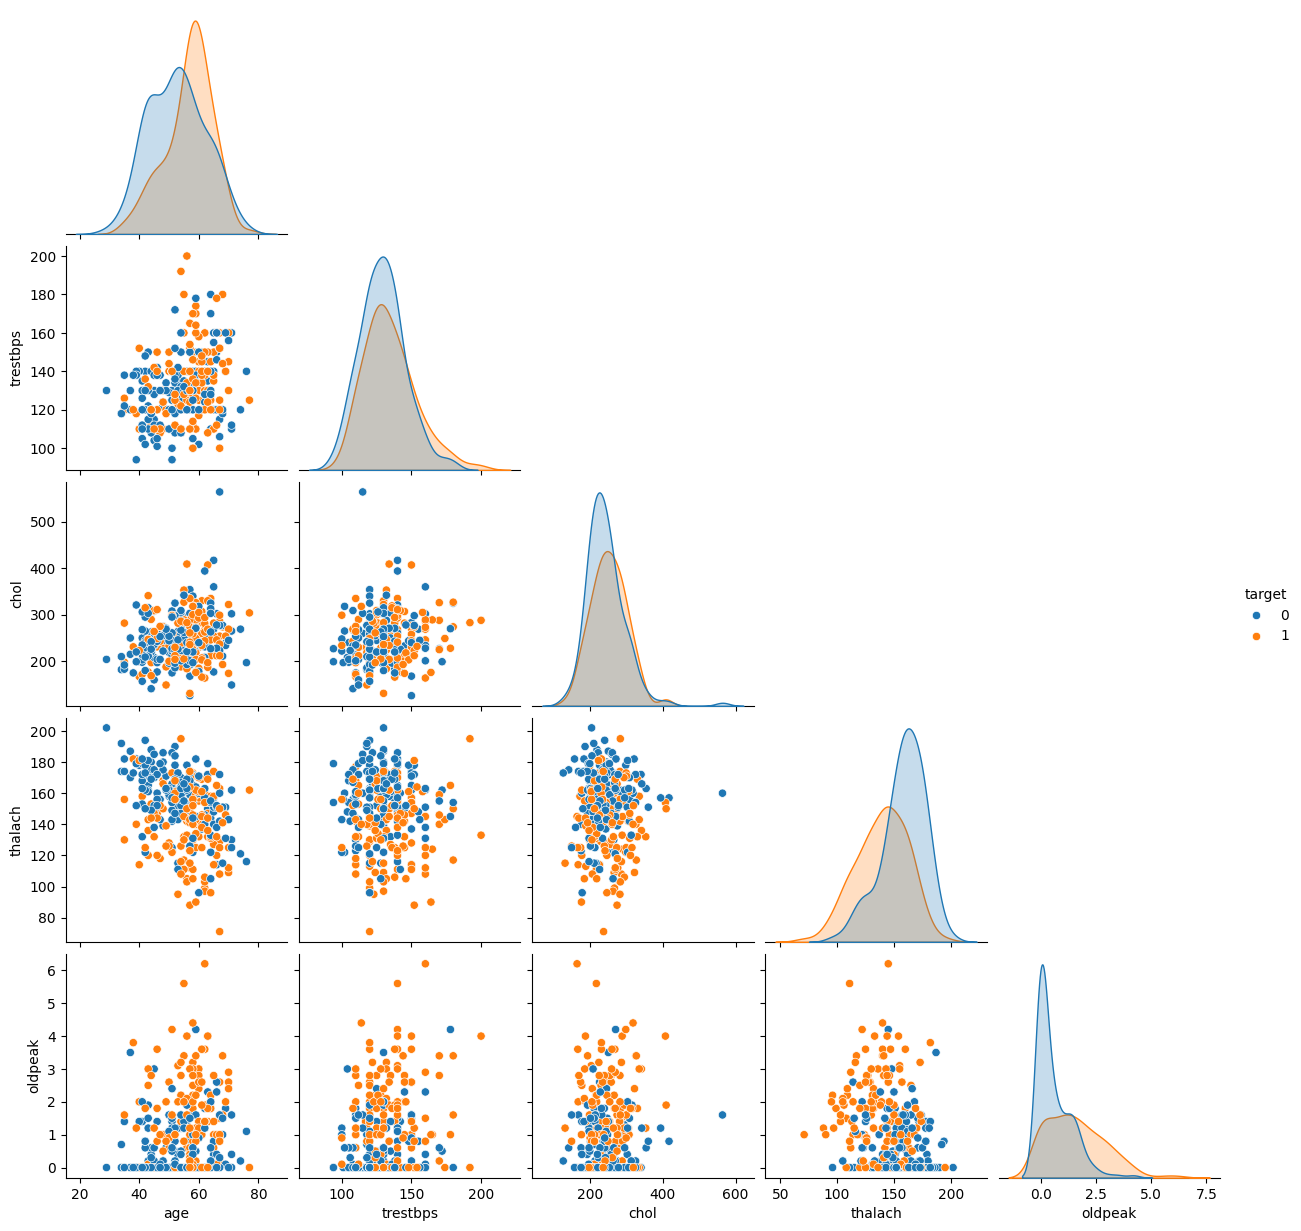

In [10]:
selected = ['age','trestbps','chol','thalach','oldpeak','target']
sns.pairplot(df[selected].dropna(), hue='target', corner=True)
plt.savefig('screenshots/pairplot_selected.png')
plt.show()

## Preprocessing: handle missing values, encode categorical variables, scale numeric features, and split train/test

In [13]:
import sys
from pathlib import Path

repo_root = next(
    (p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / "src").exists()),
    Path.cwd()
)
sys.path.insert(0, str(repo_root))

from src.preprocessing_pipeline import build_preprocessing
from sklearn.model_selection import train_test_split
import numpy as np

# Make a working copy
df2 = df.copy()
# Cast some columns as categorical (they are encoded as integers in the raw data)
cat_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal']
for c in cat_cols:
    if c in df2.columns:
        df2[c] = df2[c].astype('category')

# Separate target and features
y = df2['target']
X_raw = df2.drop(columns=['target'])

preproc = build_preprocessing(X_raw)
X_transformed = preproc.fit_transform(X_raw)
# Build feature names (numeric + one-hot names if present)
num_cols = X_raw.select_dtypes(include=['number']).columns.tolist()
cat_in_pipeline = preproc.named_transformers_.get('cat') if hasattr(preproc, 'named_transformers_') else None
cat_feature_names = []
if cat_in_pipeline is not None and len(cat_in_pipeline.named_steps) > 0:
    try:
        ohe = cat_in_pipeline.named_steps.get('onehot')
        if ohe is not None:
            cat_cols_present = [c for c in cat_cols if c in X_raw.columns]
            cat_feature_names = list(ohe.get_feature_names_out(cat_cols_present))
    except Exception:
        cat_feature_names = []
feature_names = list(num_cols) + list(cat_feature_names)
# Convert to DataFrame
X_df = pd.DataFrame(X_transformed, columns=feature_names)
# Align index with y
X_df.index = y.index

# Split
X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.2, random_state=42, stratify=y)

os.makedirs('data/processed', exist_ok=True)
train_df = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
test_df = pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)
train_df.to_csv('data/processed/train.csv', index=False)
test_df.to_csv('data/processed/test.csv', index=False)
X_df.to_csv('data/processed/heart_processed.csv', index=False)
print('Saved processed files to data/processed/')
train_df.shape, test_df.shape

TypeError: OneHotEncoder.__init__() got an unexpected keyword argument 'sparse'

### Next steps
- Use `data/processed/train.csv` and `data/processed/test.csv` for model training and evaluation.
- Log experiments with MLflow during training (already included in `src/train.py`).